# CMR Behavioral Metrics

Behavioral readouts computed purely from `recall_sims` / recall sequences.
Each metric is plotted per sweep, followed by a cross-parameter comparison.

---

## Setup

In [92]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings
warnings.filterwarnings('ignore')
import importlib
import cmr

from cmr.config import (
    N, BASE_PARAMS,
    B_rec_grid, gamma_fc_grid, eta_grid, B_encD_scale_grid,
    n_sims,
)
from cmr.sweep import sweep_one_param
from cmr.utils import _get_sweep_entry
from cmr.metrics import (
    recall_accuracy, compute_lag_crp, lag_crp_with_counts,
    conditional_forward_lag_rates, conditional_backward_lag_rates,
    unconditional_transition_summaries
)
from cmr.diagnostics_encoding import sweep_recall_counts
from cmr.visualization import (
    make_sweep_colors, _add_colorbar, line_with_colored_points,
    plot_recall_accuracy, plot_spc_sweep, plot_pfr_heatmap,
    plot_lag_crp_sweep, plot_directional_lag_rates, plot_unconditional_lag_summaries, plot_lag_crp_diagnostics,
    panel_core_behavior, panel_lag_rates_and_summaries, panel_lag_crp_diagnostics
)

In [93]:
import cmr.metrics as metrics
import cmr.visualization as viz

importlib.reload(metrics)
importlib.reload(viz)

<module 'cmr.visualization' from '/Users/yizj/Desktop/InCogLab/PTSD_MemorySegmentation/external/CMR_SEM/CMR_multiParameterSweep/cmr/visualization.py'>

## Run all four sweeps

In [50]:
sweep_B_rec = sweep_one_param(
    param_name="B_rec",
    param_grid=B_rec_grid,
    base_params=BASE_PARAMS,
    n_sims=n_sims,
    collect_diagnostics=True,
    recency_k=3,
)

  B_rec=0.2  done
  B_rec=0.4  done
  B_rec=0.6  done
  B_rec=0.8  done
  B_rec=1  done
  B_rec=1.2  done


In [51]:
sweep_gamma_fc = sweep_one_param(
    param_name="gamma_fc",
    param_grid=gamma_fc_grid,
    base_params=BASE_PARAMS,
    n_sims=n_sims,
    collect_diagnostics=True,
    recency_k=3,
)

  gamma_fc=0.2  done
  gamma_fc=0.3  done
  gamma_fc=0.4  done
  gamma_fc=0.5  done
  gamma_fc=0.6  done
  gamma_fc=0.7  done
  gamma_fc=0.8  done


In [52]:
sweep_eta = sweep_one_param(
    param_name="eta",
    param_grid=eta_grid,
    base_params=BASE_PARAMS,
    n_sims=n_sims,
    collect_diagnostics=True,
    recency_k=3,
)

  eta=0.1  done
  eta=0.2  done
  eta=0.3  done
  eta=0.4  done
  eta=0.5  done
  eta=0.6  done


In [53]:
sweep_B_enc_scale = sweep_one_param(
    param_name="B_encD_scale",
    param_grid=B_encD_scale_grid,
    base_params=BASE_PARAMS,
    n_sims=n_sims,
    collect_diagnostics=True,
    recency_k=3,
)

  B_encD_scale=0.2  done
  B_encD_scale=0.4  done
  B_encD_scale=0.6  done
  B_encD_scale=0.8  done
  B_encD_scale=1  done


---
## $B_{rec}$

### Recall accuracy

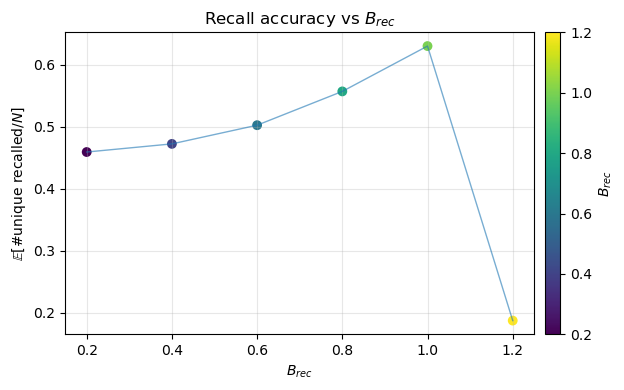

In [54]:
plot_recall_accuracy(sweep_B_rec, B_rec_grid, r"$B_{rec}$")

### SPC

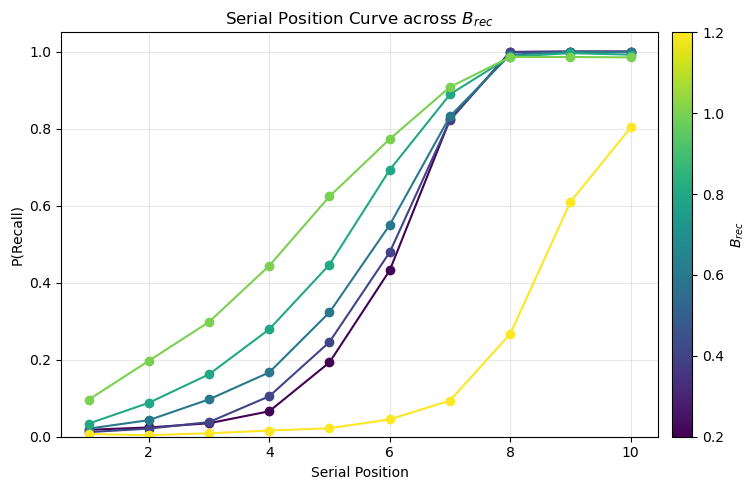

In [55]:
plot_spc_sweep(sweep_B_rec, B_rec_grid, r"$B_{rec}$")

### PFR

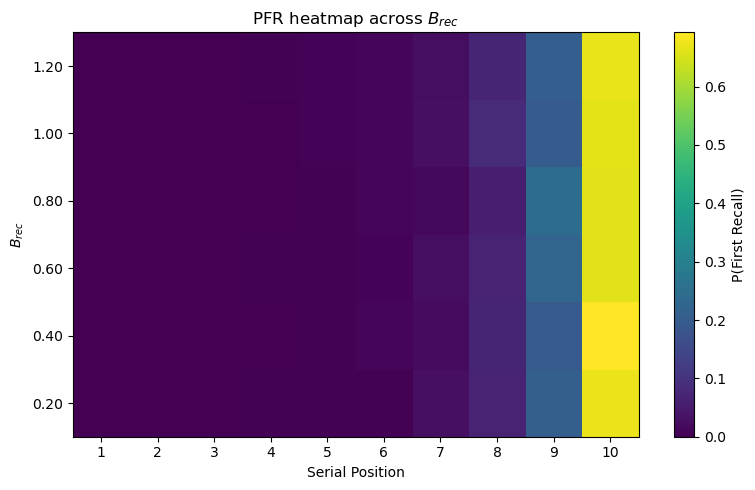

In [56]:
plot_pfr_heatmap(sweep_B_rec, B_rec_grid, r"$B_{rec}$")

### Lag-CRP

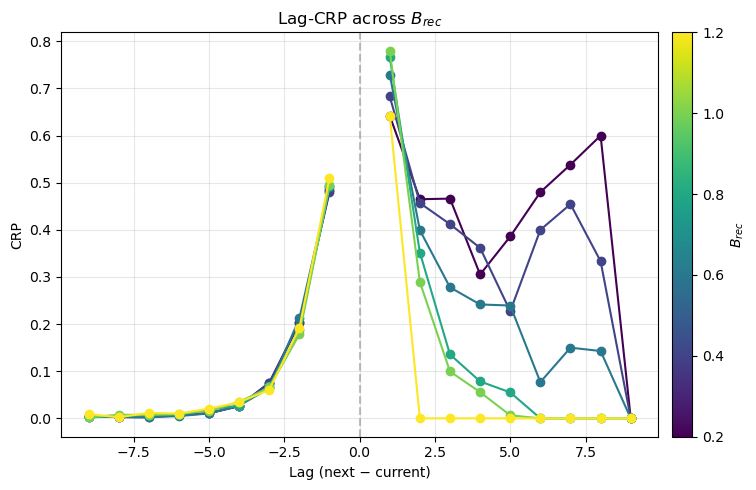

In [57]:
plot_lag_crp_sweep(sweep_B_rec, B_rec_grid, r"$B_{rec}$")

### Conditional lag rates

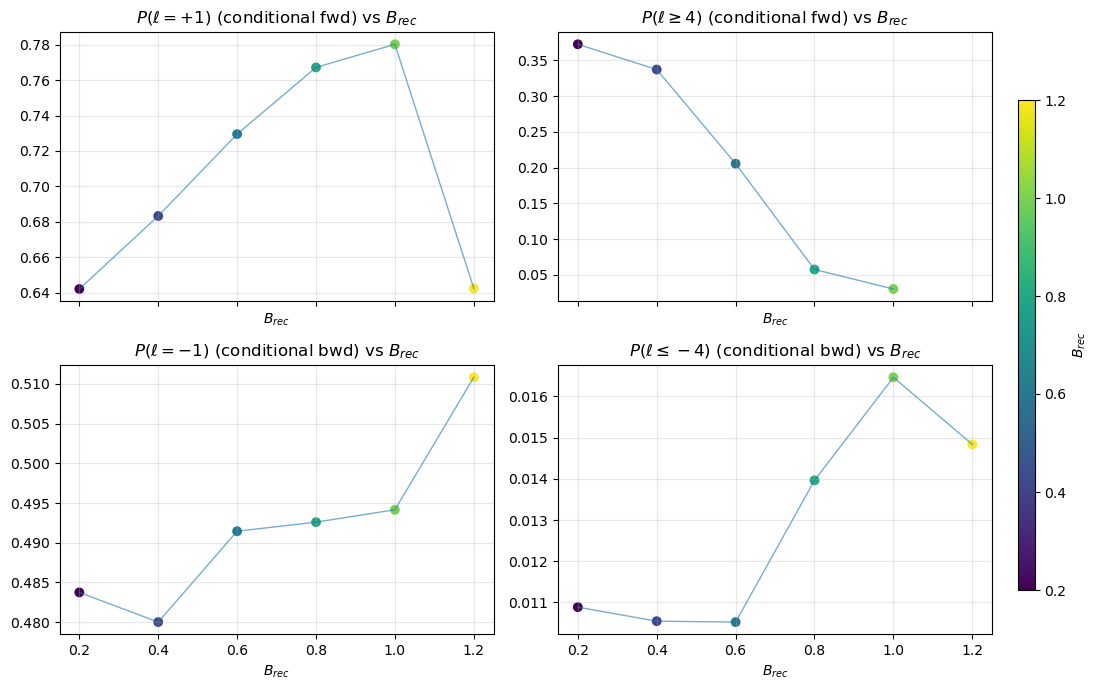

In [58]:
plot_directional_lag_rates(sweep_B_rec, B_rec_grid, r"$B_{rec}$")

### Unconditional lag summaries

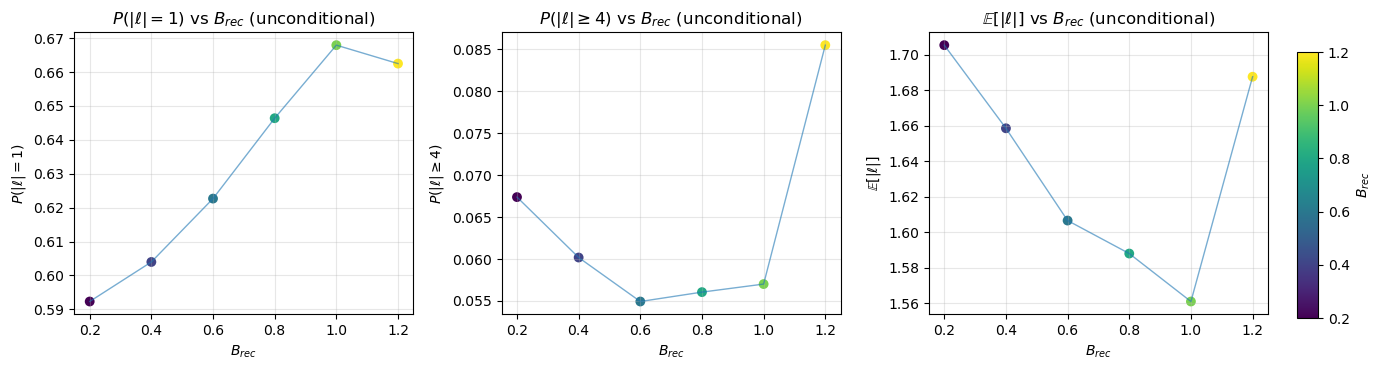

In [59]:
plot_unconditional_lag_summaries(sweep_B_rec, B_rec_grid, r"$B_{rec}$")

### Conditional absolute-value lag summaries (opportunity-corrected)

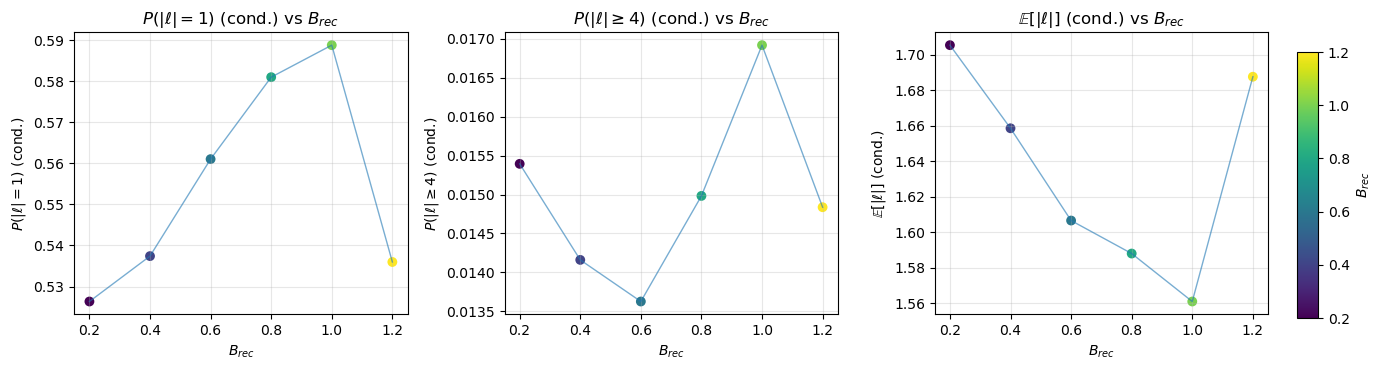

In [60]:
param_grid = np.asarray(B_rec_grid, dtype=float)
colors, norm, cmap = make_sweep_colors(param_grid)
k = 4

pa1 = np.full(len(param_grid), np.nan)
pak = np.full(len(param_grid), np.nan)
ma  = np.full(len(param_grid), np.nan)

for i, v in enumerate(param_grid):
    rs = _get_sweep_entry(sweep_B_rec, v)["recall_sims"]
    lags, crp, num, den = lag_crp_with_counts(rs, N)
    pa1[i], pak[i], ma[i] = conditional_abs_lag_summaries(lags, num, den, large_lag_thresh=k)

fig, axs = plt.subplots(1, 3, figsize=(14, 3.8), sharex=True)
titles_labs = [
    (pa1, r"$P(|\ell|=1)$ (cond.)"),
    (pak, rf"$P(|\ell|\geq {k})$ (cond.)"),
    (ma,  r"$\mathbb{E}[|\ell|]$ (cond.)"),
]
for ax, (y, lab) in zip(axs, titles_labs):
    line_with_colored_points(ax, param_grid, y, colors)
    ax.set_title(lab + r" vs $B_{rec}$")
    ax.set_xlabel(r"$B_{rec}$")
    ax.set_ylabel(lab)
    ax.grid(alpha=0.3)

fig.tight_layout(rect=[0, 0, 0.92, 1])
cax = fig.add_axes([0.93, 0.15, 0.015, 0.7])
fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap), cax=cax).set_label(r"$B_{rec}$")
plt.show()

### Lag-CRP diagnostics (CRP + opportunities + transitions)

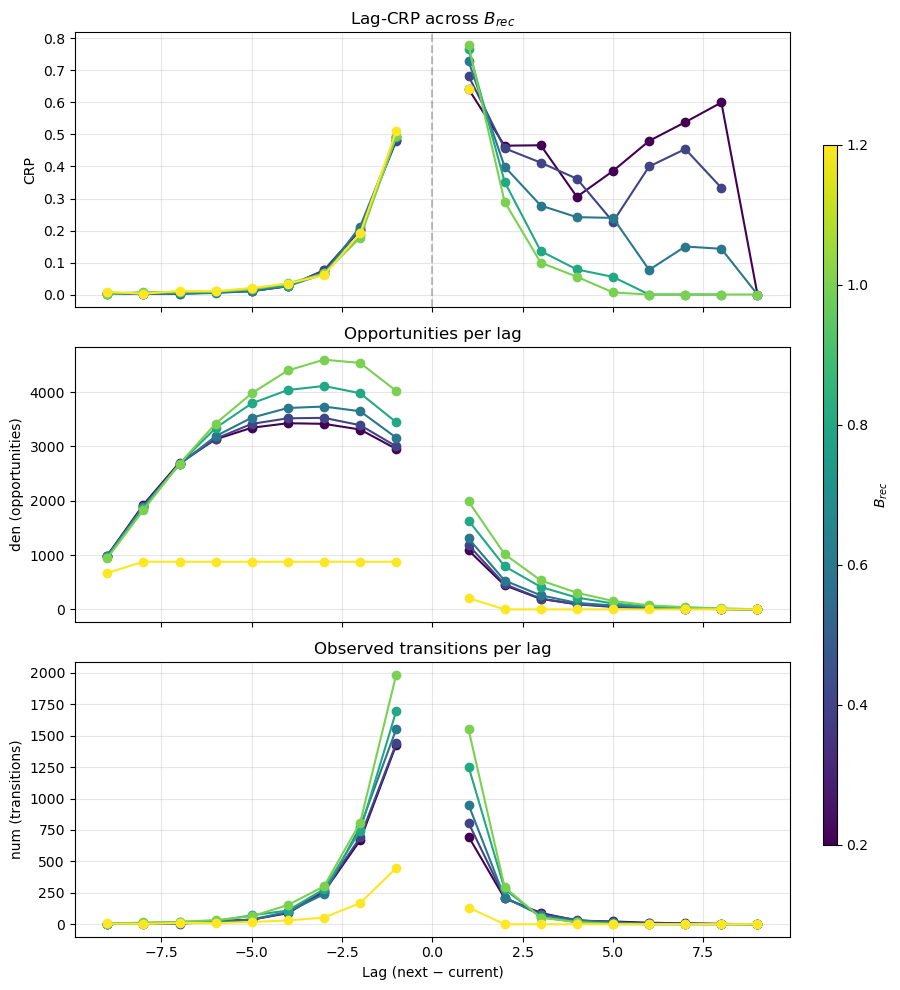

In [61]:
plot_lag_crp_diagnostics(sweep_B_rec, B_rec_grid, param_name=r"$B_{rec}$")

---
## $\gamma_{fc}$

### Recall accuracy

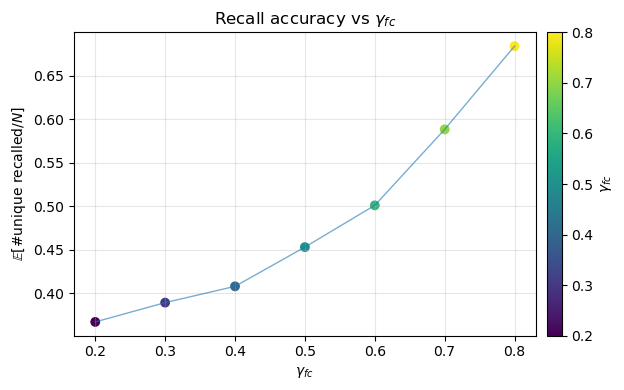

In [62]:
plot_recall_accuracy(sweep_gamma_fc, gamma_fc_grid, r"$\gamma_{fc}$")

### SPC

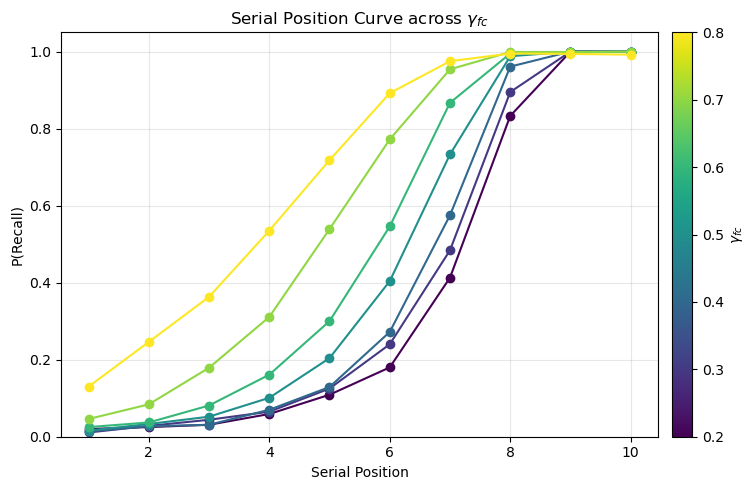

In [63]:
plot_spc_sweep(sweep_gamma_fc, gamma_fc_grid, r"$\gamma_{fc}$")

### PFR

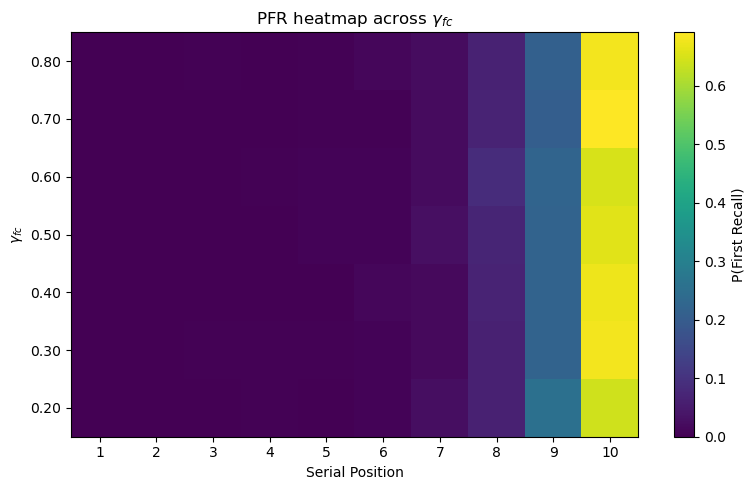

In [64]:
plot_pfr_heatmap(sweep_gamma_fc, gamma_fc_grid, r"$\gamma_{fc}$")

### Lag-CRP

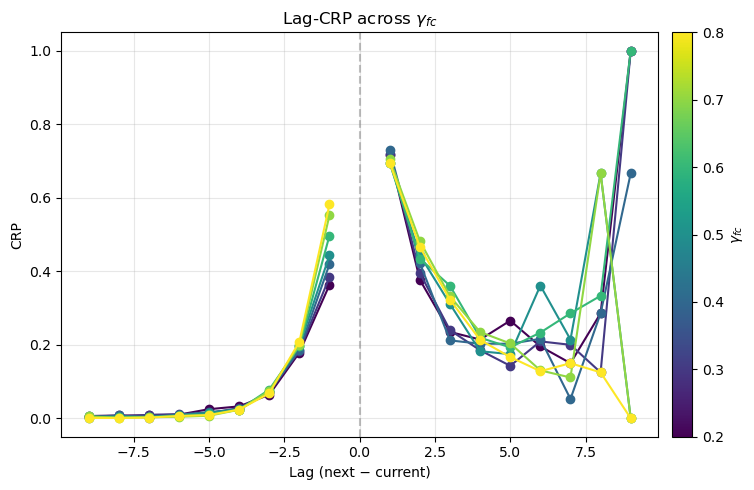

In [65]:
plot_lag_crp_sweep(sweep_gamma_fc, gamma_fc_grid, r"$\gamma_{fc}$")

### Conditional lag rates

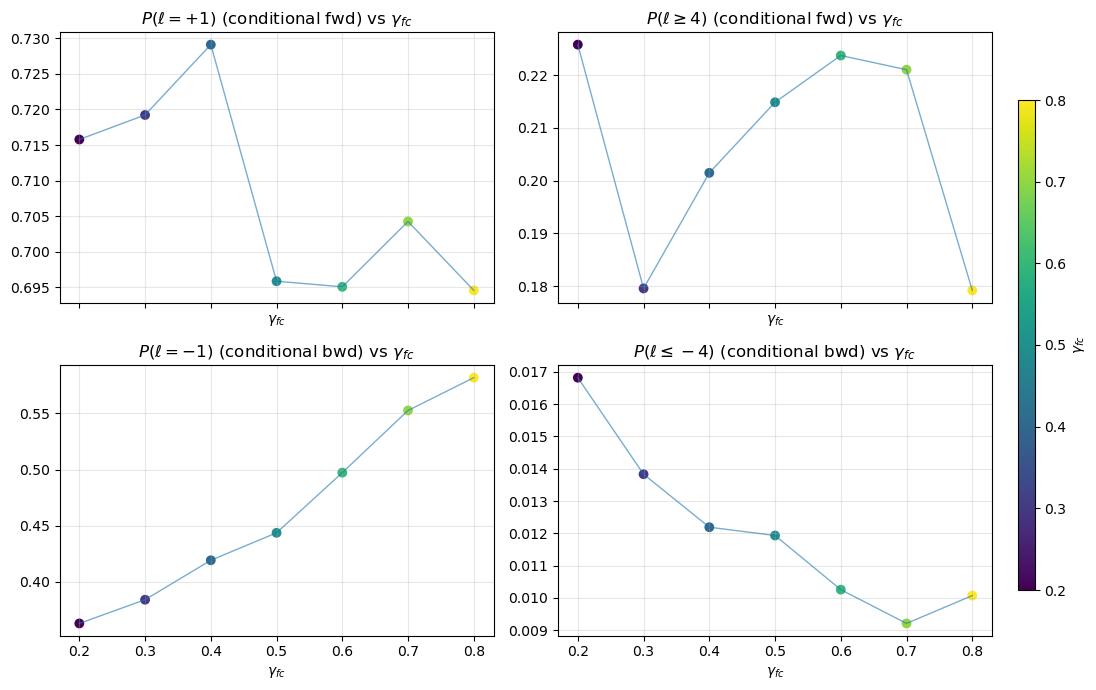

In [66]:
plot_directional_lag_rates(sweep_gamma_fc, gamma_fc_grid, r"$\gamma_{fc}$")

### Unconditional lag summaries

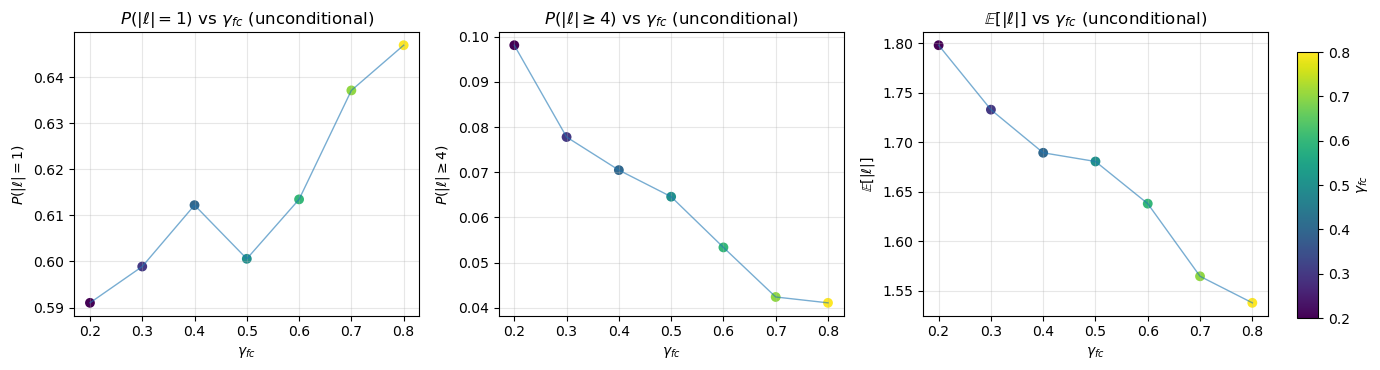

In [67]:
plot_unconditional_lag_summaries(sweep_gamma_fc, gamma_fc_grid, r"$\gamma_{fc}$")

### Conditional absolute-value lag summaries (opportunity-corrected)

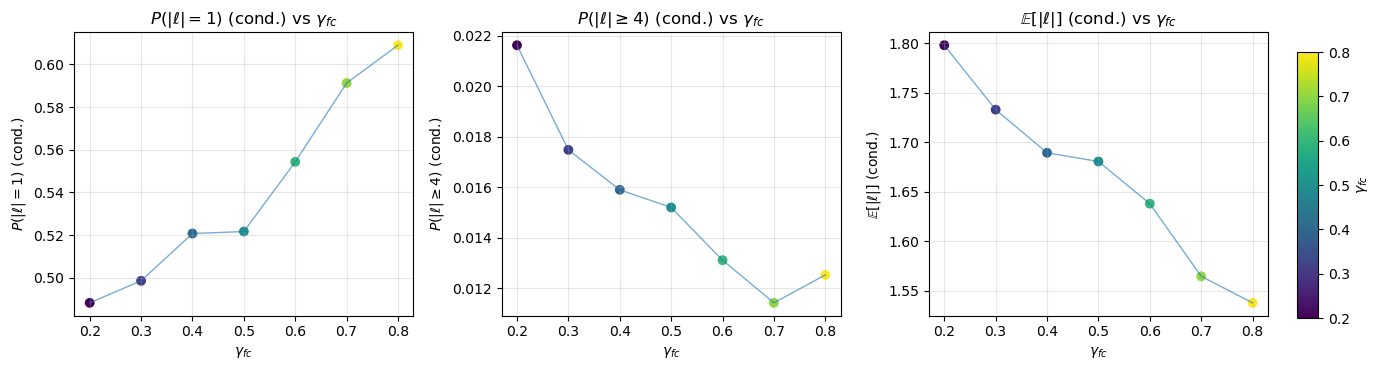

In [68]:
param_grid = np.asarray(gamma_fc_grid, dtype=float)
colors, norm, cmap = make_sweep_colors(param_grid)
k = 4

pa1 = np.full(len(param_grid), np.nan)
pak = np.full(len(param_grid), np.nan)
ma  = np.full(len(param_grid), np.nan)

for i, v in enumerate(param_grid):
    rs = _get_sweep_entry(sweep_gamma_fc, v)["recall_sims"]
    lags, crp, num, den = lag_crp_with_counts(rs, N)
    pa1[i], pak[i], ma[i] = conditional_abs_lag_summaries(lags, num, den, large_lag_thresh=k)

fig, axs = plt.subplots(1, 3, figsize=(14, 3.8), sharex=True)
titles_labs = [
    (pa1, r"$P(|\ell|=1)$ (cond.)"),
    (pak, rf"$P(|\ell|\geq {k})$ (cond.)"),
    (ma,  r"$\mathbb{E}[|\ell|]$ (cond.)"),
]
for ax, (y, lab) in zip(axs, titles_labs):
    line_with_colored_points(ax, param_grid, y, colors)
    ax.set_title(lab + r" vs $\gamma_{fc}$")
    ax.set_xlabel(r"$\gamma_{fc}$")
    ax.set_ylabel(lab)
    ax.grid(alpha=0.3)

fig.tight_layout(rect=[0, 0, 0.92, 1])
cax = fig.add_axes([0.93, 0.15, 0.015, 0.7])
fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap), cax=cax).set_label(r"$\gamma_{fc}$")
plt.show()

### Lag-CRP diagnostics (CRP + opportunities + transitions)

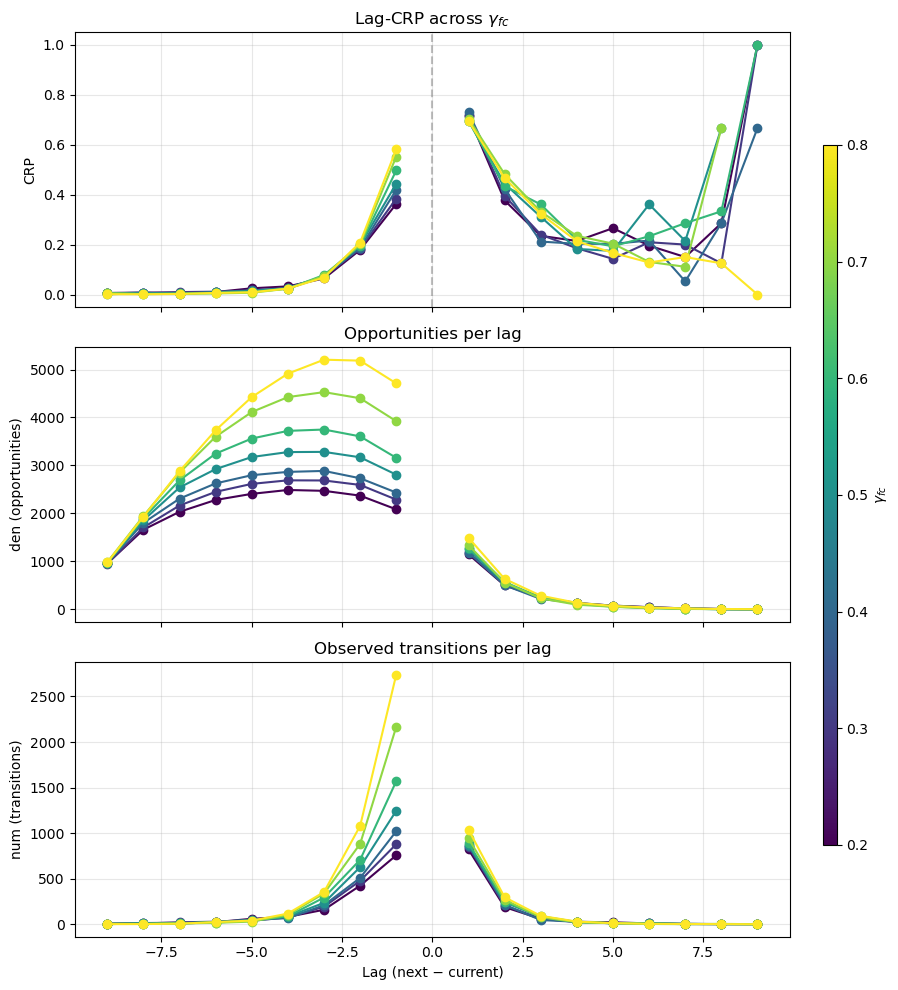

In [69]:
plot_lag_crp_diagnostics(sweep_gamma_fc, gamma_fc_grid, param_name=r"$\gamma_{fc}$")

---
## $\eta$

### Recall accuracy

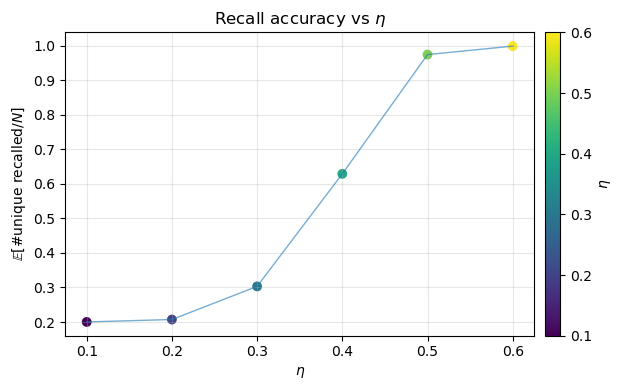

In [70]:
plot_recall_accuracy(sweep_eta, eta_grid, r"$\eta$")

### SPC

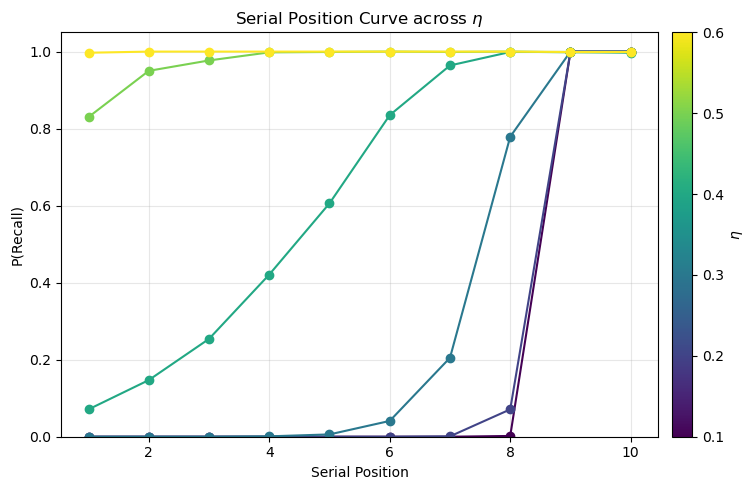

In [71]:
plot_spc_sweep(sweep_eta, eta_grid, r"$\eta$")

### PFR

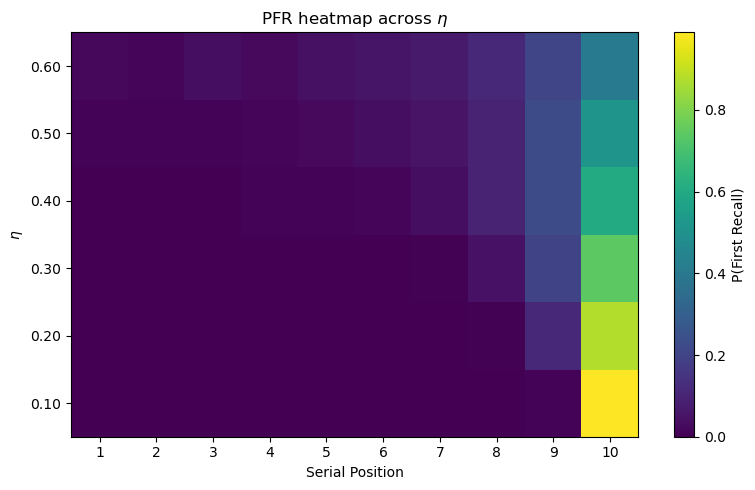

In [72]:
plot_pfr_heatmap(sweep_eta, eta_grid, r"$\eta$")

### Lag-CRP

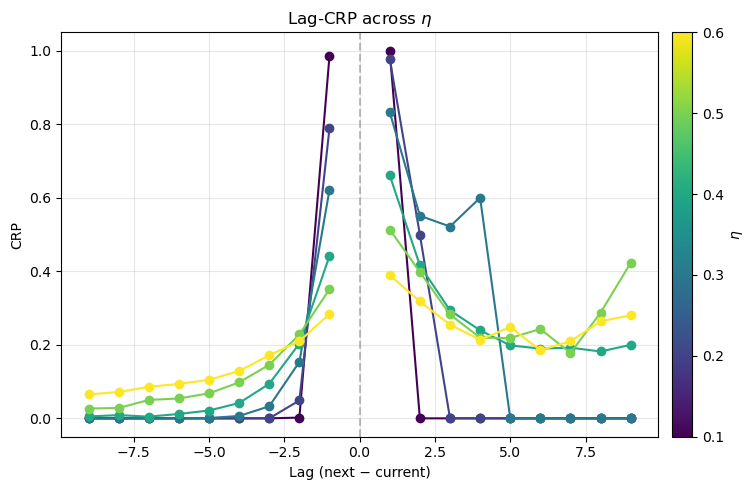

In [73]:
plot_lag_crp_sweep(sweep_eta, eta_grid, r"$\eta$")

### Conditional lag rates

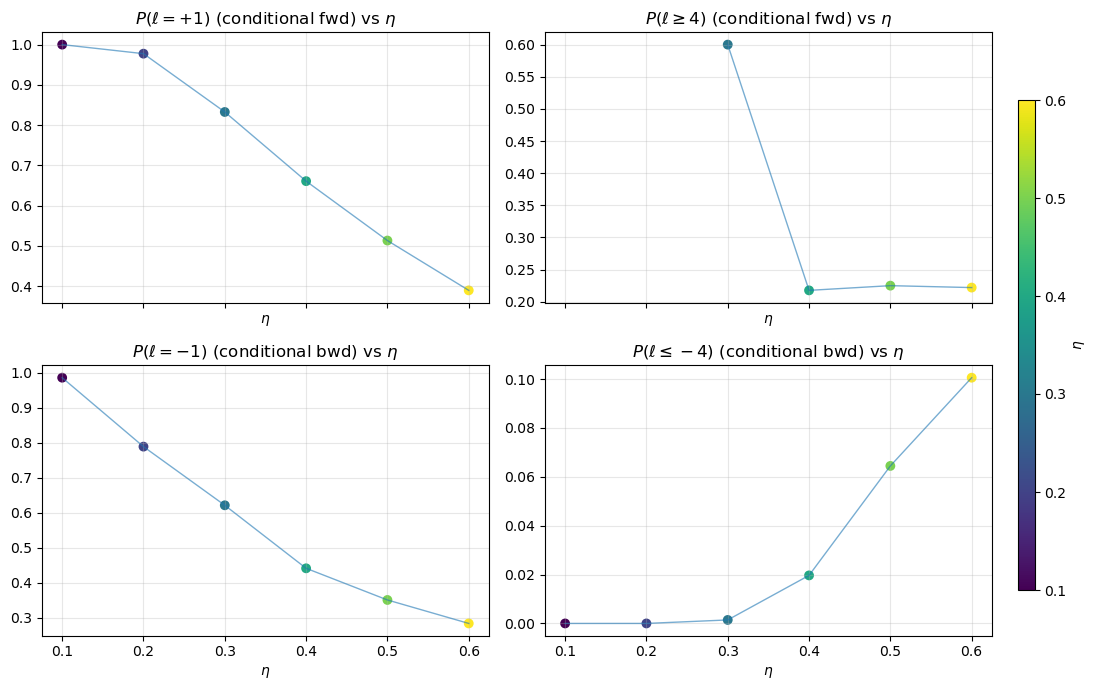

In [74]:
plot_directional_lag_rates(sweep_eta, eta_grid, r"$\eta$")

### Unconditional lag summaries

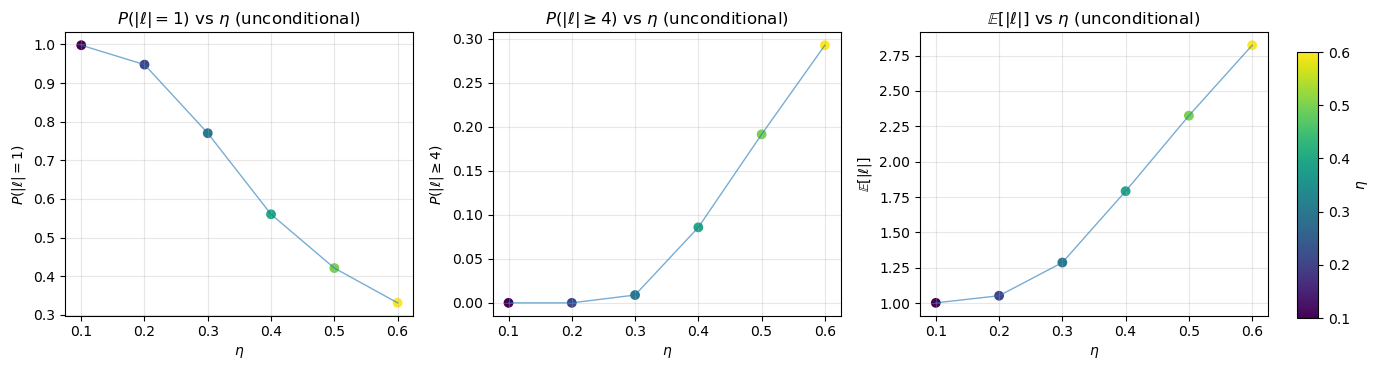

In [75]:
plot_unconditional_lag_summaries(sweep_eta, eta_grid, r"$\eta$")

### Conditional absolute-value lag summaries (opportunity-corrected)

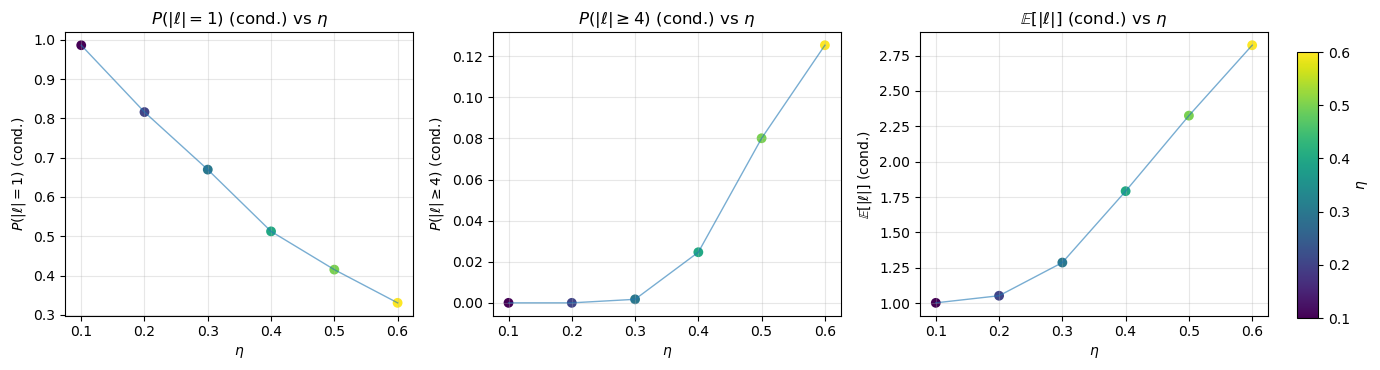

In [76]:
param_grid = np.asarray(eta_grid, dtype=float)
colors, norm, cmap = make_sweep_colors(param_grid)
k = 4

pa1 = np.full(len(param_grid), np.nan)
pak = np.full(len(param_grid), np.nan)
ma  = np.full(len(param_grid), np.nan)

for i, v in enumerate(param_grid):
    rs = _get_sweep_entry(sweep_eta, v)["recall_sims"]
    lags, crp, num, den = lag_crp_with_counts(rs, N)
    pa1[i], pak[i], ma[i] = conditional_abs_lag_summaries(lags, num, den, large_lag_thresh=k)

fig, axs = plt.subplots(1, 3, figsize=(14, 3.8), sharex=True)
titles_labs = [
    (pa1, r"$P(|\ell|=1)$ (cond.)"),
    (pak, rf"$P(|\ell|\geq {k})$ (cond.)"),
    (ma,  r"$\mathbb{E}[|\ell|]$ (cond.)"),
]
for ax, (y, lab) in zip(axs, titles_labs):
    line_with_colored_points(ax, param_grid, y, colors)
    ax.set_title(lab + r" vs $\eta$")
    ax.set_xlabel(r"$\eta$")
    ax.set_ylabel(lab)
    ax.grid(alpha=0.3)

fig.tight_layout(rect=[0, 0, 0.92, 1])
cax = fig.add_axes([0.93, 0.15, 0.015, 0.7])
fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap), cax=cax).set_label(r"$\eta$")
plt.show()

---
## $B_{enc}$ scale

### Recall accuracy

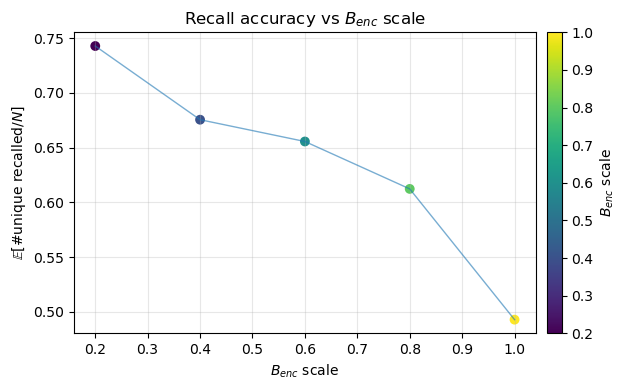

In [77]:
plot_recall_accuracy(sweep_B_enc_scale, B_encD_scale_grid, r"$B_{enc}$ scale")

### SPC

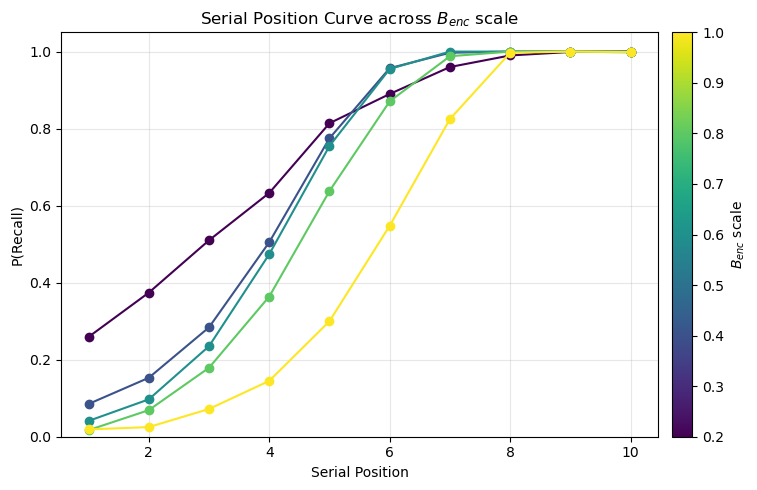

In [78]:
plot_spc_sweep(sweep_B_enc_scale, B_encD_scale_grid, r"$B_{enc}$ scale")

### PFR

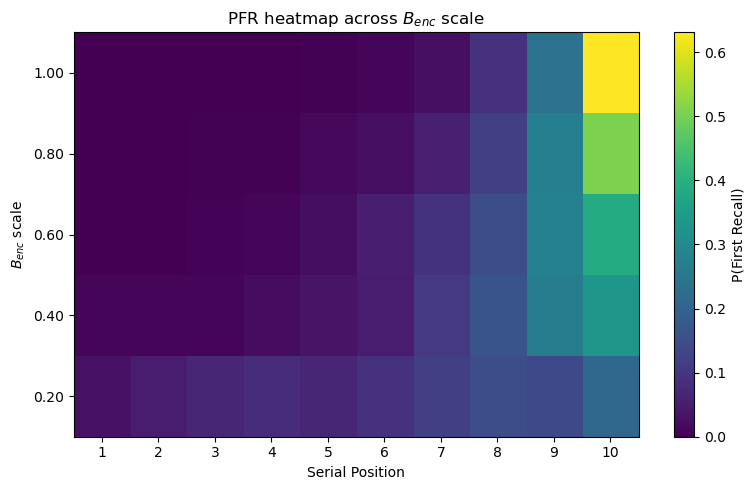

In [79]:
plot_pfr_heatmap(sweep_B_enc_scale, B_encD_scale_grid, r"$B_{enc}$ scale")

### Lag-CRP

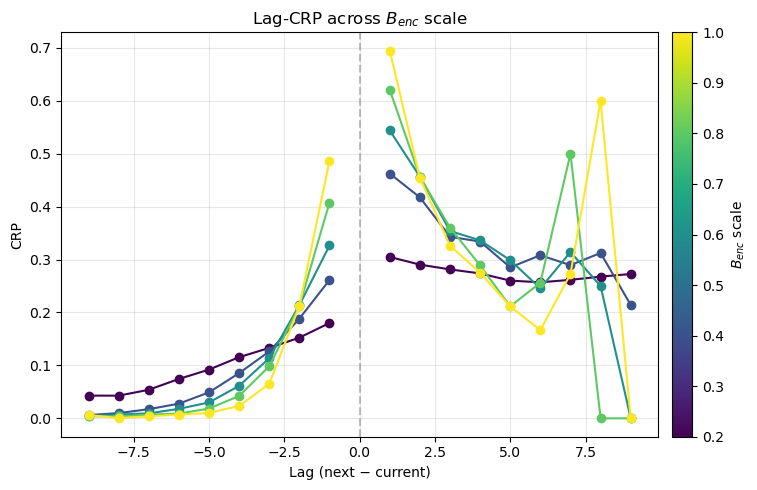

In [80]:
plot_lag_crp_sweep(sweep_B_enc_scale, B_encD_scale_grid, r"$B_{enc}$ scale")

### Conditional lag rates

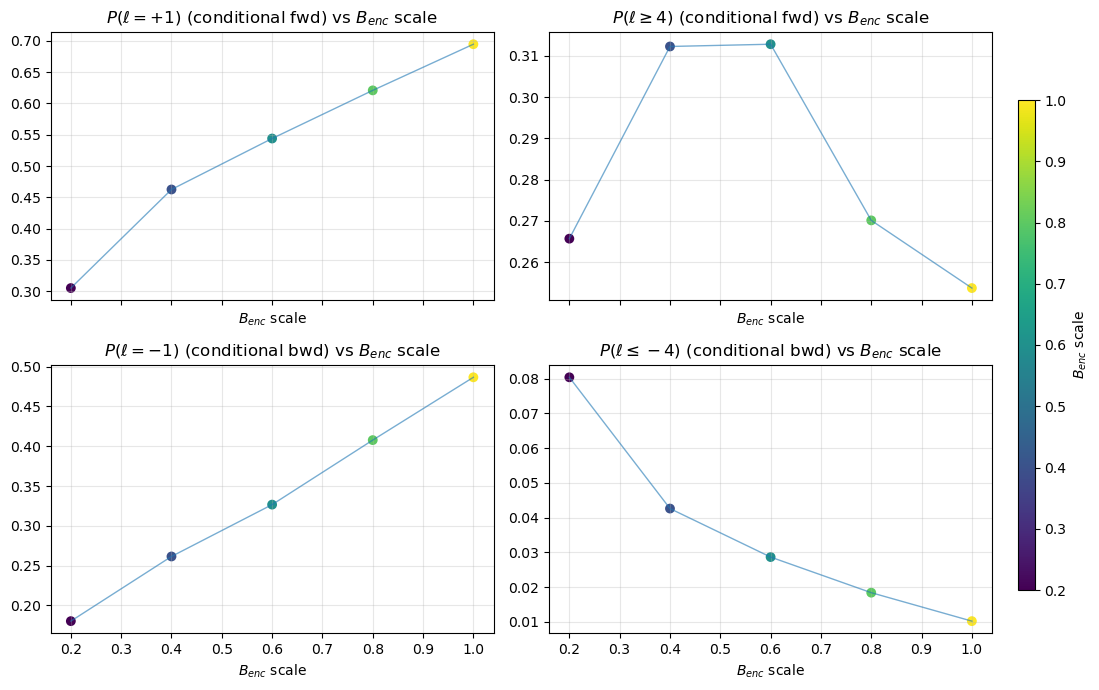

In [81]:
plot_directional_lag_rates(sweep_B_enc_scale, B_encD_scale_grid, r"$B_{enc}$ scale")

### Unconditional lag summaries

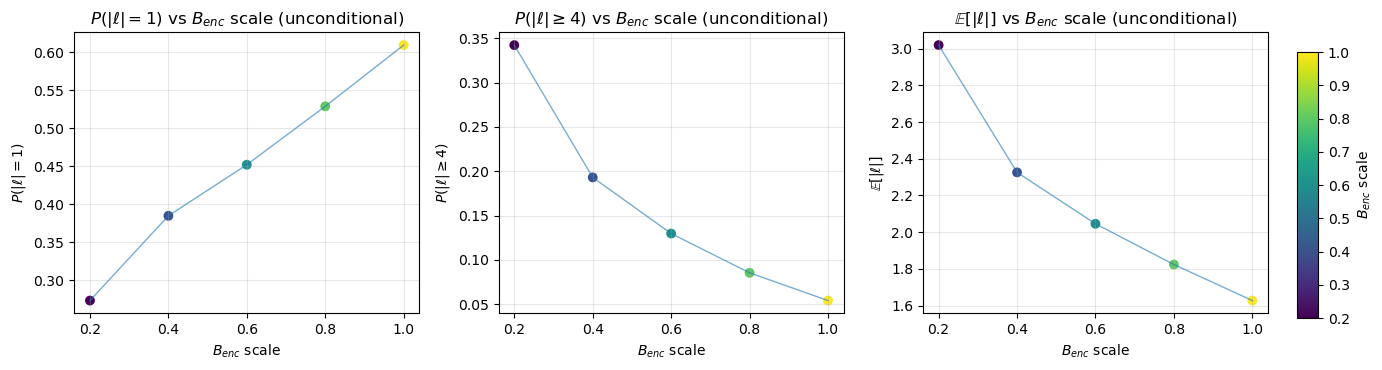

In [82]:
plot_unconditional_lag_summaries(sweep_B_enc_scale, B_encD_scale_grid, r"$B_{enc}$ scale")

### Conditional absolute-value lag summaries (opportunity-corrected)

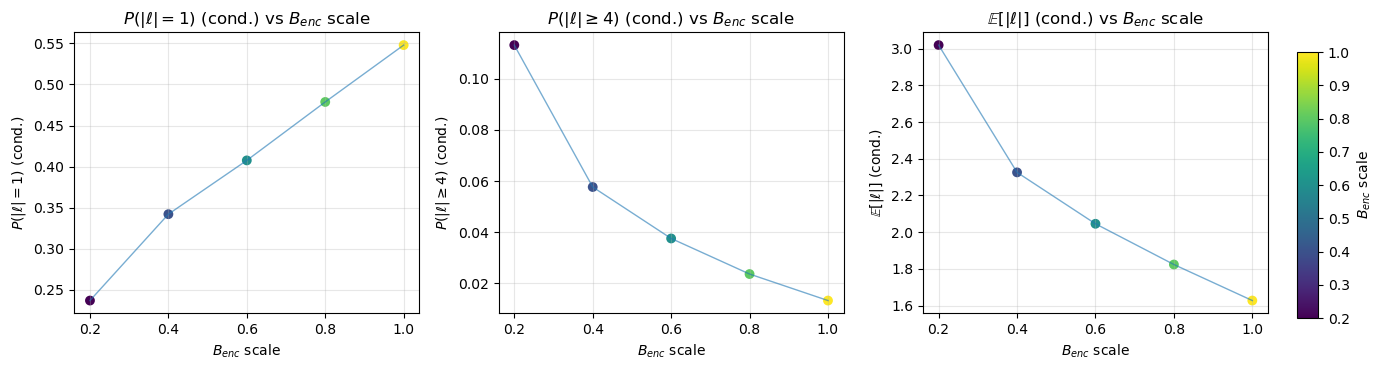

In [83]:
param_grid = np.asarray(B_encD_scale_grid, dtype=float)
colors, norm, cmap = make_sweep_colors(param_grid)
k = 4

pa1 = np.full(len(param_grid), np.nan)
pak = np.full(len(param_grid), np.nan)
ma  = np.full(len(param_grid), np.nan)

for i, v in enumerate(param_grid):
    rs = _get_sweep_entry(sweep_B_enc_scale, v)["recall_sims"]
    lags, crp, num, den = lag_crp_with_counts(rs, N)
    pa1[i], pak[i], ma[i] = conditional_abs_lag_summaries(lags, num, den, large_lag_thresh=k)

fig, axs = plt.subplots(1, 3, figsize=(14, 3.8), sharex=True)
titles_labs = [
    (pa1, r"$P(|\ell|=1)$ (cond.)"),
    (pak, rf"$P(|\ell|\geq {k})$ (cond.)"),
    (ma,  r"$\mathbb{E}[|\ell|]$ (cond.)"),
]
for ax, (y, lab) in zip(axs, titles_labs):
    line_with_colored_points(ax, param_grid, y, colors)
    ax.set_title(lab + r" vs $B_{enc}$ scale")
    ax.set_xlabel(r"$B_{enc}$ scale")
    ax.set_ylabel(lab)
    ax.grid(alpha=0.3)

fig.tight_layout(rect=[0, 0, 0.92, 1])
cax = fig.add_axes([0.93, 0.15, 0.015, 0.7])
fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap), cax=cax).set_label(r"$B_{enc}$ scale")
plt.show()

### Mean items recalled per trial

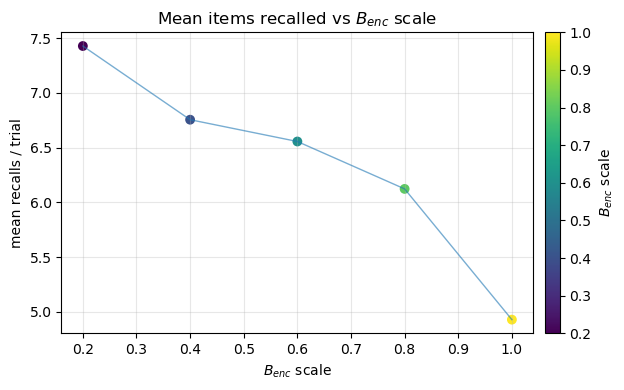

In [84]:
counts = sweep_recall_counts(sweep_B_enc_scale, B_encD_scale_grid)
param_grid = np.asarray(B_encD_scale_grid, dtype=float)
colors, norm_c, cmap_c = make_sweep_colors(param_grid)

fig, ax = plt.subplots(figsize=(6.5, 4))
line_with_colored_points(ax, param_grid, counts, colors)
ax.set_title(r"Mean items recalled vs $B_{enc}$ scale")
ax.set_xlabel(r"$B_{enc}$ scale"); ax.set_ylabel("mean recalls / trial")
ax.grid(alpha=0.3)
_add_colorbar(fig, ax, norm_c, cmap_c, r"$B_{enc}$ scale")
fig.tight_layout(); plt.show()

---
## Cross-parameter comparison

In [85]:
sweeps = [
    (sweep_B_rec,       B_rec_grid,        r"$B_{rec}$"),
    (sweep_gamma_fc,    gamma_fc_grid,     r"$\gamma_{fc}$"),
    (sweep_eta,         eta_grid,          r"$\eta$"),
    (sweep_B_enc_scale, B_encD_scale_grid, r"$B_{enc}$ scale"),
]

### Core behavioral metrics

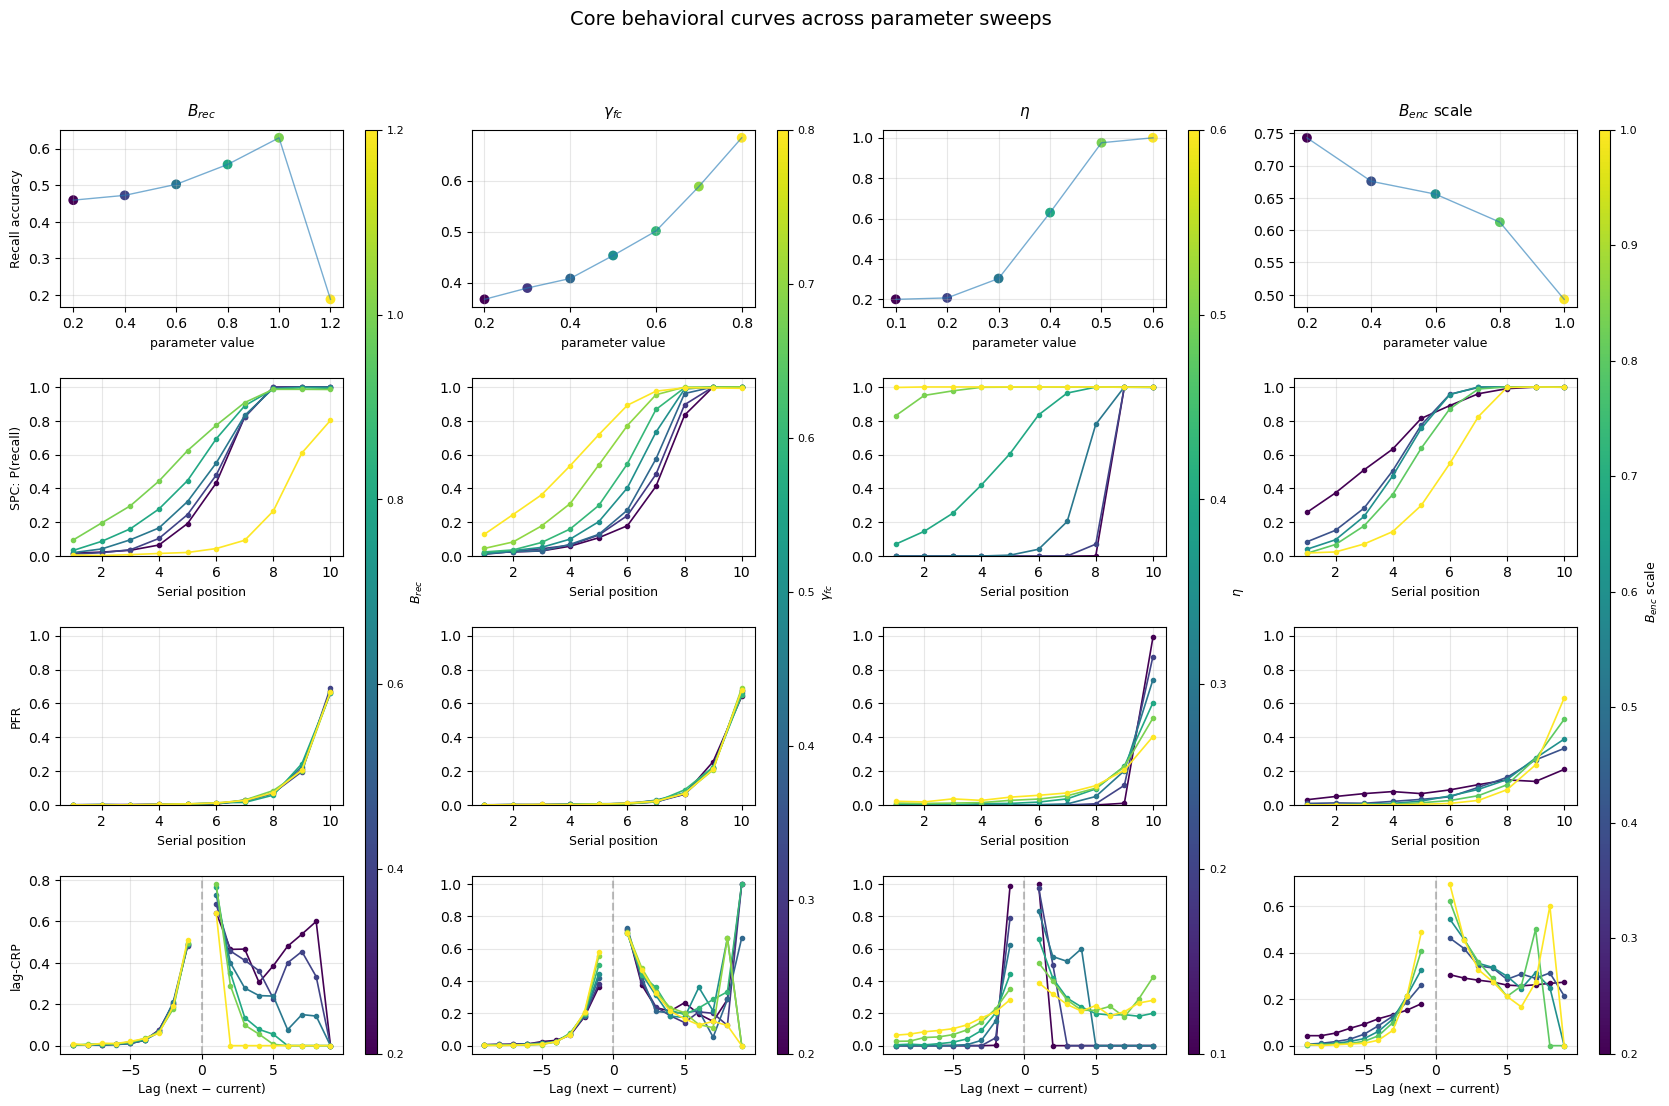

In [86]:
nrows, ncols = 4, 4
fig = plt.figure(figsize=(20, 12))

# 1. Define outer grid (one cell for each sweep)
# wspace here controls the gap between the 4 main columns
outer_gs = fig.add_gridspec(1, ncols, wspace=0.3)

axs = np.empty((nrows, ncols), dtype=object)
caxs = np.empty(ncols, dtype=object)

for col in range(ncols):
    # 2. Define INNER grid for each column
    # width_ratios: [Plot Width, Colorbar Width]
    # wspace: horizontal gap between plot and colorbar
    # hspace: vertical gap between rows
    inner_gs = outer_gs[0, col].subgridspec(
        nrows, 2, 
        width_ratios=[1, 0.04], 
        wspace=0.15, 
        hspace=0.4
    )

    for r in range(nrows):
        axs[r, col] = fig.add_subplot(inner_gs[r, 0])

    # 3. Create colorbar axis spanning all rows in 2nd column of inner_gs
    caxs[col] = fig.add_subplot(inner_gs[:, 1])


for col, (sweep_res, grid, label) in enumerate(sweeps):
    grid = np.asarray(grid, float)
    colors, norm, cmap = make_sweep_colors(grid, cmap_name="viridis")
    serial = np.arange(1, N + 1)

    # --- row 0: recall accuracy ---
    ax = axs[0, col]
    y = np.array([
        recall_accuracy(_get_sweep_entry(sweep_res, v)["recall_sims"], N=N, unique=True)
        for v in grid
    ], float)
    line_with_colored_points(ax, grid, y, colors)
    ax.set_title(label, fontsize=11, pad=10)
    ax.set_xlabel("parameter value", fontsize=9)
    if col == 0:
        ax.set_ylabel("Recall accuracy", fontsize=9)
    ax.grid(alpha=0.3)

    # --- row 1: SPC ---
    ax = axs[1, col]
    for v, c in zip(grid, colors):
        spc = _get_sweep_entry(sweep_res, v)["SPC"]
        ax.plot(serial, spc, color=c, marker="o", lw=1.2, ms=3)
    if col == 0:
        ax.set_ylabel("SPC: P(recall)", fontsize=9)
    ax.set_xlabel("Serial position", fontsize=9)
    ax.set_ylim(0, 1.05)
    ax.grid(alpha=0.3)

    # --- row 2: PFR ---
    ax = axs[2, col]
    for v, c in zip(grid, colors):
        pfr = _get_sweep_entry(sweep_res, v)["PFR"]
        ax.plot(serial, pfr, color=c, marker="o", lw=1.2, ms=3)
    if col == 0:
        ax.set_ylabel("PFR", fontsize=9)
    ax.set_xlabel("Serial position", fontsize=9)
    ax.set_ylim(0, 1.05)
    ax.grid(alpha=0.3)

    # --- row 3: lag-CRP ---
    ax = axs[3, col]
    for v, c in zip(grid, colors):
        rs = _get_sweep_entry(sweep_res, v)["recall_sims"]
        lags, crp = compute_lag_crp(rs, N)
        neg = lags < 0
        pos = lags > 0
        ax.plot(lags[neg], crp[neg], color=c, marker="o", lw=1.2, ms=3)
        ax.plot(lags[pos], crp[pos], color=c, marker="o", lw=1.2, ms=3)
    ax.axvline(0, color="gray", ls="--", alpha=0.5)
    if col == 0:
        ax.set_ylabel("lag-CRP", fontsize=9)
    ax.set_xlabel("Lag (next − current)", fontsize=9)
    ax.grid(alpha=0.3)

    # --- colorbar for this sweep column ---
    sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=caxs[col])
    cbar.set_label(label, fontsize=9)
    caxs[col].tick_params(labelsize=8)

fig.suptitle("Core behavioral curves across parameter sweeps", fontsize=14, y=0.98)
plt.show()

### Lag-CRP diagnostics

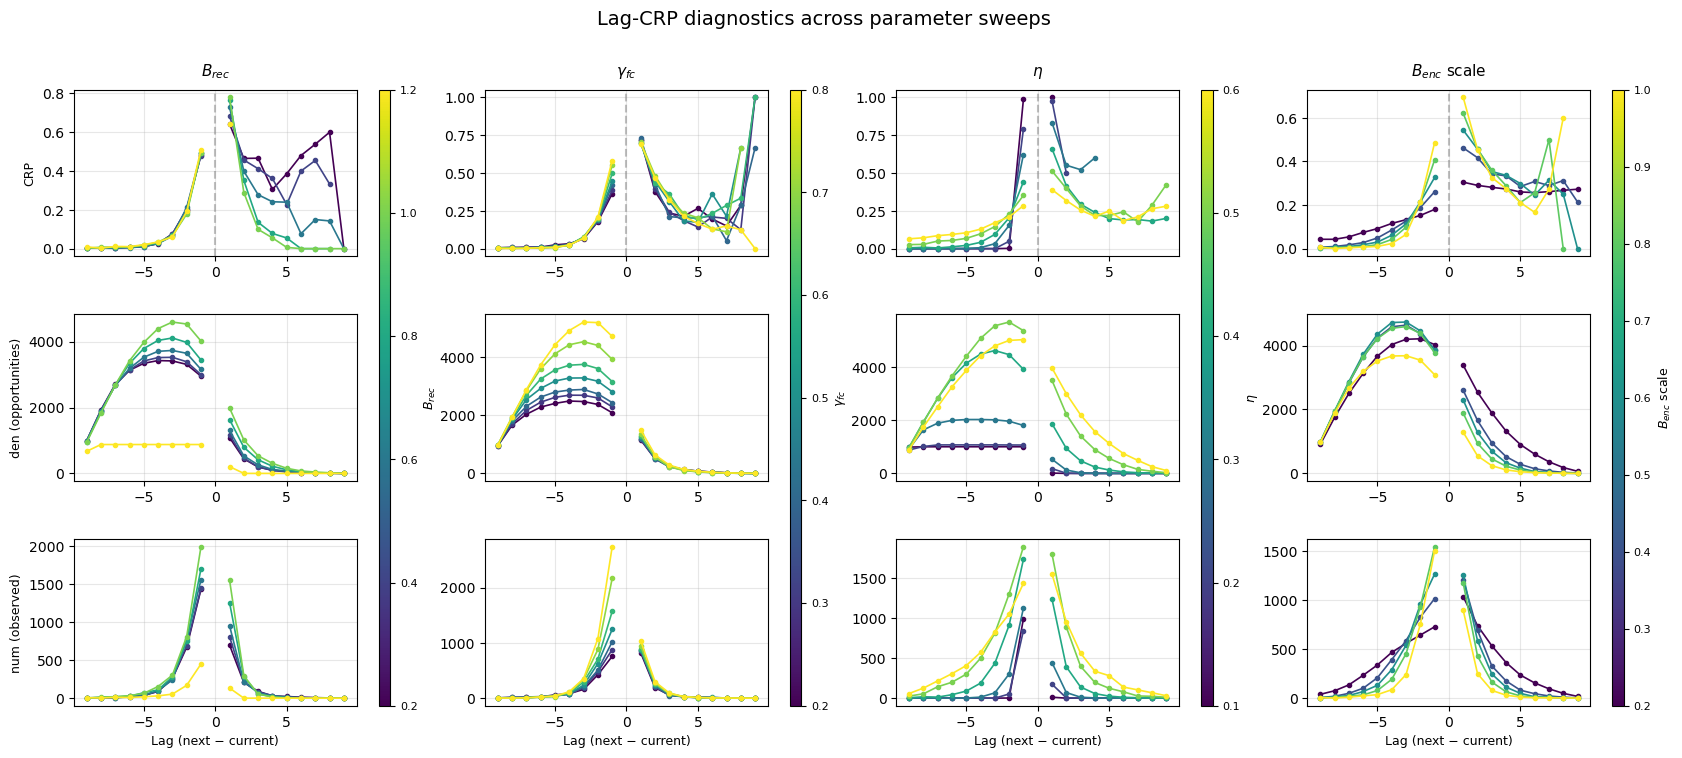

In [87]:
nrows, ncols = 3, 4
fig = plt.figure(figsize=(20, 8))

outer_gs = fig.add_gridspec(1, ncols, wspace=0.3)

axs  = np.empty((nrows, ncols), dtype=object)
caxs = np.empty(ncols, dtype=object)

for col in range(ncols):
    inner_gs = outer_gs[0, col].subgridspec(
        nrows, 2,
        width_ratios=[1, 0.04],
        wspace=0.15,
        hspace=0.35
    )
    for r in range(nrows):
        axs[r, col] = fig.add_subplot(inner_gs[r, 0])
    caxs[col] = fig.add_subplot(inner_gs[:, 1])

for col, (sweep_res, grid, label) in enumerate(sweeps):
    grid = np.asarray(grid, float)
    colors, norm, cmap = make_sweep_colors(grid, cmap_name="viridis")

    for v, c in zip(grid, colors):
        rs = _get_sweep_entry(sweep_res, v)["recall_sims"]
        lags, crp, num, den = lag_crp_with_counts(rs, N)

        neg = lags < 0
        pos = lags > 0

        axs[0, col].plot(lags[neg], crp[neg], color=c, marker="o", lw=1.2, ms=3)
        axs[0, col].plot(lags[pos], crp[pos], color=c, marker="o", lw=1.2, ms=3)

        axs[1, col].plot(lags[neg], den[neg], color=c, marker="o", lw=1.2, ms=3)
        axs[1, col].plot(lags[pos], den[pos], color=c, marker="o", lw=1.2, ms=3)

        axs[2, col].plot(lags[neg], num[neg], color=c, marker="o", lw=1.2, ms=3)
        axs[2, col].plot(lags[pos], num[pos], color=c, marker="o", lw=1.2, ms=3)

    axs[0, col].axvline(0, color="gray", ls="--", alpha=0.5)
    axs[0, col].set_title(label, fontsize=11, pad=10)

    if col == 0:
        axs[0, col].set_ylabel("CRP", fontsize=9)
        axs[1, col].set_ylabel("den (opportunities)", fontsize=9)
        axs[2, col].set_ylabel("num (observed)", fontsize=9)

    axs[2, col].set_xlabel("Lag (next − current)", fontsize=9)

    for r in range(nrows):
        axs[r, col].grid(alpha=0.3)

    sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=caxs[col])
    cbar.set_label(label, fontsize=9)
    caxs[col].tick_params(labelsize=8)

fig.suptitle("Lag-CRP diagnostics across parameter sweeps", fontsize=14, y=0.98)
plt.show()

### Conditional lag +1 and lag -1 probabilities

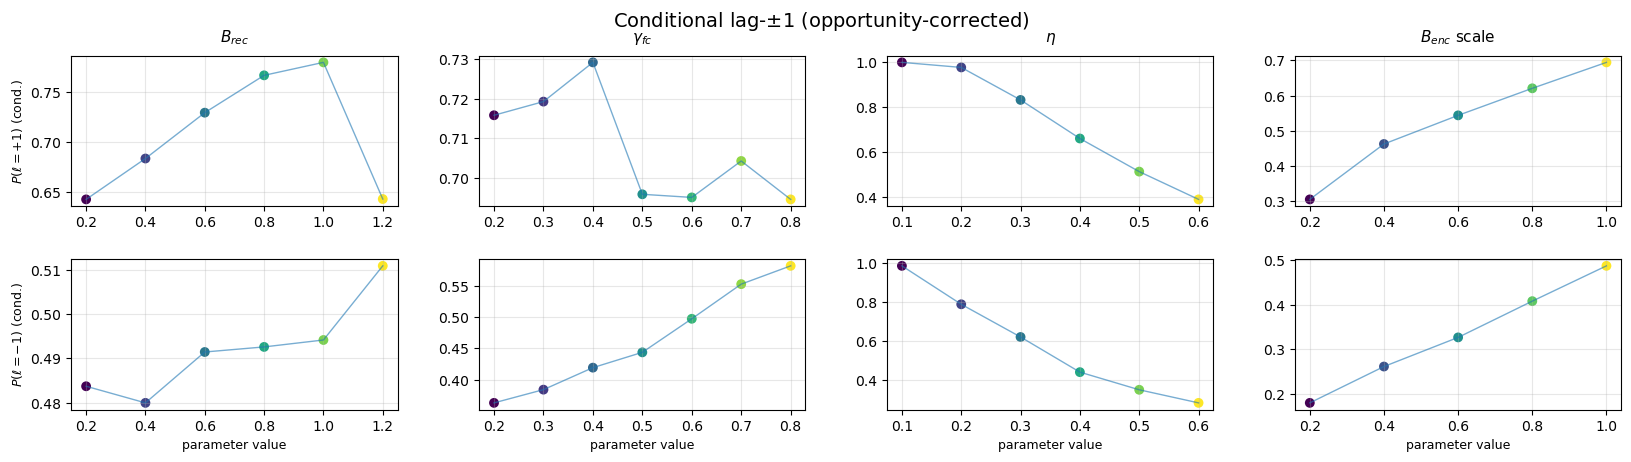

In [95]:
# --- only conditional +1 and -1 ---
nrows, ncols = 2, 4
fig = plt.figure(figsize=(20, 4.6))

outer_gs = fig.add_gridspec(1, ncols, wspace=0.25)
axs = np.empty((nrows, ncols), dtype=object)

for col in range(ncols):
    inner_gs = outer_gs[0, col].subgridspec(nrows, 1, hspace=0.35)
    for r in range(nrows):
        axs[r, col] = fig.add_subplot(inner_gs[r, 0])

k = 4  # large-lag threshold (only used in your helper calls; not needed for +/-1)

sweeps = [
    (sweep_B_rec,       B_rec_grid,        r"$B_{rec}$"),
    (sweep_gamma_fc,    gamma_fc_grid,     r"$\gamma_{fc}$"),
    (sweep_eta,         eta_grid,          r"$\eta$"),
    (sweep_B_enc_scale, B_encD_scale_grid, r"$B_{enc}$ scale"),
]

row_specs = [
    (r"$P(\ell=+1)$ (cond.)",
     lambda rs: (lambda lags, crp, num, den:
                 conditional_forward_lag_rates(lags, num, den, large_lag_thresh=k)[0]
                )(*lag_crp_with_counts(rs, N))),
    (r"$P(\ell=-1)$ (cond.)",
     lambda rs: (lambda lags, crp, num, den:
                 conditional_backward_lag_rates(lags, num, den, large_lag_thresh=k)[0]
                )(*lag_crp_with_counts(rs, N))),
]

for col, (sweep, grid, label) in enumerate(sweeps):
    grid = np.asarray(grid, dtype=float)
    colors, norm, cmap = make_sweep_colors(grid, cmap_name="viridis")

    for row, (ylabel, metric_fn) in enumerate(row_specs):
        ax = axs[row, col]
        y = np.array([metric_fn(_get_sweep_entry(sweep, v)["recall_sims"]) for v in grid], dtype=float)

        line_with_colored_points(ax, grid, y, colors)
        ax.grid(alpha=0.3)

        if row == 0:
            ax.set_title(label, fontsize=11, pad=10)
        if col == 0:
            ax.set_ylabel(ylabel, fontsize=9)
        if row == nrows - 1:
            ax.set_xlabel("parameter value", fontsize=9)

fig.suptitle(r"Conditional lag-$\pm 1$ (opportunity-corrected)", fontsize=14, y=0.98)
plt.show()

### Conditional & unconditional lag-1 & lag ≥ 4 probabilities

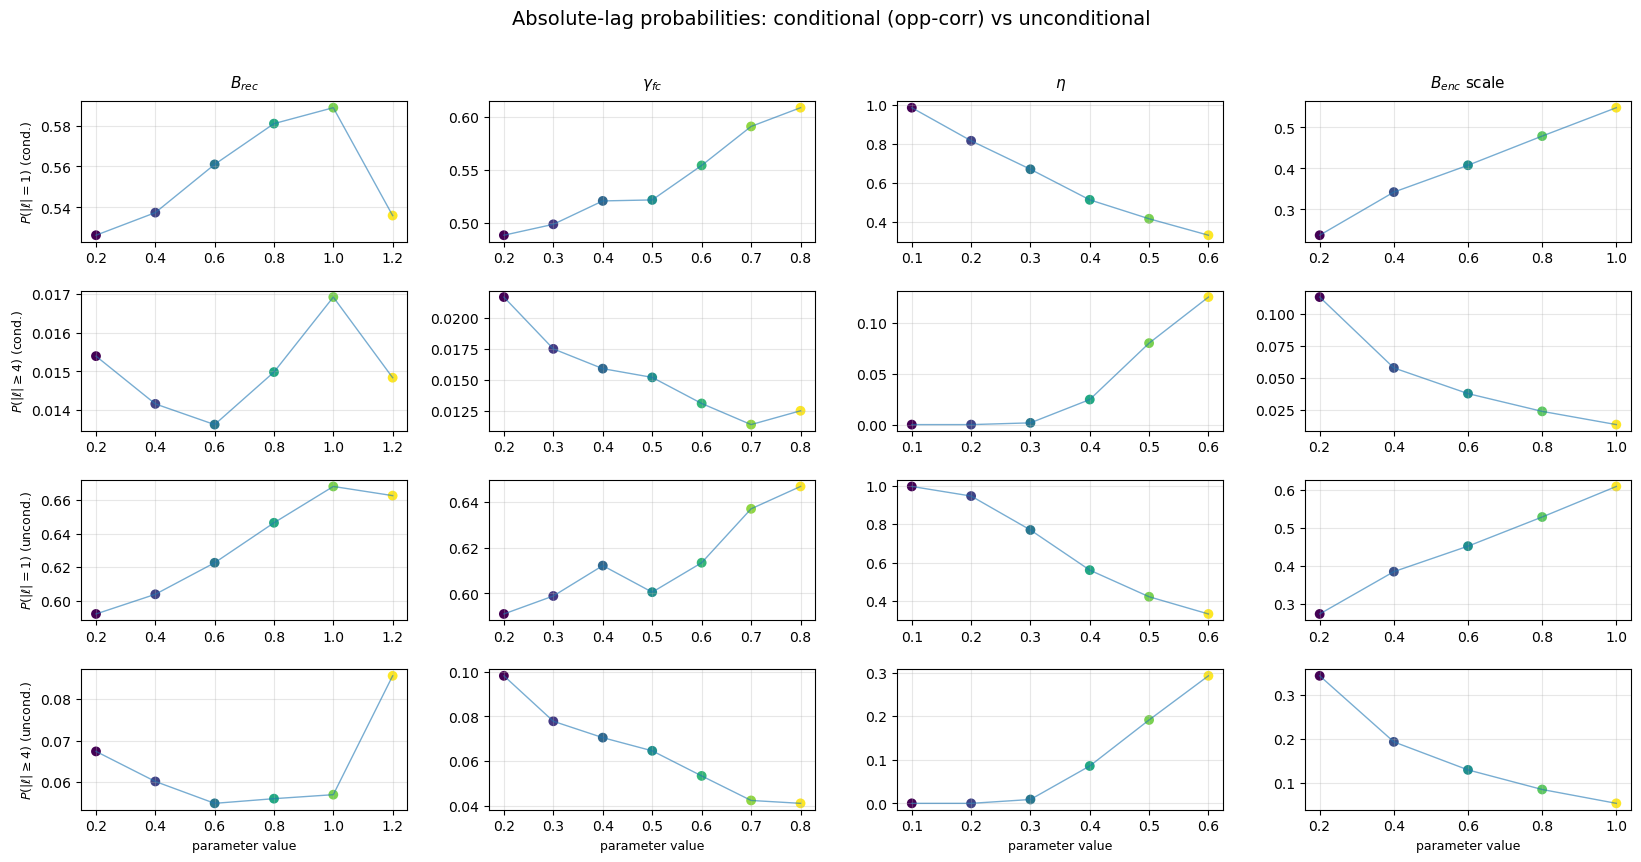

In [100]:
k = 4

sweeps = [
    (sweep_B_rec,       B_rec_grid,        r"$B_{rec}$"),
    (sweep_gamma_fc,    gamma_fc_grid,     r"$\gamma_{fc}$"),
    (sweep_eta,         eta_grid,          r"$\eta$"),
    (sweep_B_enc_scale, B_encD_scale_grid, r"$B_{enc}$ scale"),
]

nrows1, ncols = 4, 4
fig1 = plt.figure(figsize=(20, 9.2))
outer_gs1 = fig1.add_gridspec(1, ncols, wspace=0.25)
axs1 = np.empty((nrows1, ncols), dtype=object)

for col in range(ncols):
    inner_gs = outer_gs1[0, col].subgridspec(nrows1, 1, hspace=0.35)
    for r in range(nrows1):
        axs1[r, col] = fig1.add_subplot(inner_gs[r, 0])

row_specs1 = [
    (rf"$P(|\ell|=1)$ (cond.)",
     lambda rs: (lambda lags, crp, num, den:
                 conditional_abs_lag_summaries(lags, num, den, large_lag_thresh=k)[0]
                )(*lag_crp_with_counts(rs, N))),

    (rf"$P(|\ell|\geq {k})$ (cond.)",
     lambda rs: (lambda lags, crp, num, den:
                 conditional_abs_lag_summaries(lags, num, den, large_lag_thresh=k)[1]
                )(*lag_crp_with_counts(rs, N))),

    (rf"$P(|\ell|=1)$ (uncond.)",
     lambda rs: unconditional_transition_summaries(rs, large_lag_thresh=k)[0]),

    (rf"$P(|\ell|\geq {k})$ (uncond.)",
     lambda rs: unconditional_transition_summaries(rs, large_lag_thresh=k)[1]),
]

for col, (sweep, grid, label) in enumerate(sweeps):
    grid = np.asarray(grid, dtype=float)
    colors, norm, cmap = make_sweep_colors(grid, cmap_name="viridis")

    for row, (ylabel, metric_fn) in enumerate(row_specs1):
        ax = axs1[row, col]
        y = np.array([metric_fn(_get_sweep_entry(sweep, v)["recall_sims"]) for v in grid], dtype=float)

        line_with_colored_points(ax, grid, y, colors)
        ax.grid(alpha=0.3)

        if row == 0:
            ax.set_title(label, fontsize=11, pad=10)
        if col == 0:
            ax.set_ylabel(ylabel, fontsize=9)
        if row == nrows1 - 1:
            ax.set_xlabel("parameter value", fontsize=9)

fig1.suptitle(r"Absolute-lag probabilities: conditional (opp-corr) vs unconditional", fontsize=14, y=0.98)
plt.show()
